# Qualtrics Data Cleaning Demo

Rachel Rapier (University of Wisconsin, Madison)  
July 8, 2026

This manuscript cleans the data set and analyzes the relationship between enjoyment of social interaction and use of public transportation.

## Standard Imports & Loacking Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_context('talk')

# Read in the Data

In [2]:
dataA = pd.read_csv('data_orig/PRCAProlificExport_FileA.csv')
dataB = pd.read_csv('data_orig/PRCAProlificExport_FileB.csv')
dataC = pd.read_csv('data_orig/PRCAQualtricsExport_FileC.csv')

questions = pd.read_csv('data_dictionary.csv')


# rename the columns to variable_name and question
questions.rename(columns={questions.columns[0]: 'variable_name', questions.columns[1]: 'question'}, inplace=True)

In [3]:
#| label: view-questions
#| echo: true
# with pd.option_context('display.max_colwidth', None):
#     display(questions.transpose())

Markdown(
  questions.transpose().to_markdown()
)

## Merge Files

In [4]:
#| echo: true
# First merge dataB with dataA (both have Participant id column)
data_all = pd.merge(dataA, dataB, how = 'outer')

# Then merge the result with dataC (Q0 in dataC contains Participant id that matches Participant id in dataA/dataB)
data_all = pd.merge(data_all, dataC, left_on='Participant id', right_on='Q0', how='right')

#create an indexing column because participant id a long string of numbers and we want to simplify it. This index will be used as the participant id. Then move it to the first column

data_all['p_id'] = data_all.index
data_all = data_all[['p_id'] + [col for col in data_all.columns if col != 'p_id']]

# Display the merged dataframe info
print(f"Merged dataframe shape: {data_all.shape}")
print(f"Columns in merged dataframe: {data_all.columns.tolist()}")
print(data_all.head())

Merged dataframe shape: (273, 39)
Columns in merged dataframe: ['p_id', 'Submission id', 'Participant id', 'Started at', 'Completed at', 'Time taken', 'Age', 'Total approvals', 'Sex', 'Country of residence', 'Student status', 'Employment status', 'StartDate', 'EndDate', 'Duration (in seconds)', 'ResponseId', 'LocationLatitude', 'LocationLongitude', 'Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q26', 'Q27', 'Q28', 'Q29', 'Q20', 'Q21', 'Q18.1', 'Q19']
   p_id                                      Submission id  \
0     0                                                NaN   
1     1  f3943bf594d541b81fbde88288600739a47ee97b0524c1...   
2     2  0799215a062ddef149fa49bfe069e3ff2b4b79f08f5b01...   
3     3  b5ee447916c6e86a0d40fb2f55eaad40ab43137efe45b7...   
4     4  fbd66de9b2d0670e12cea181c97fa0bec80b2a64567569...   

                                      Participant id  Started at  \
0                                                NaN         NaN  

# Data Cleaning & Prep

## Response mapping to numeric values

In [5]:
#| label: response-mapping
df = data_all
#make all responses lowercase
df = df.apply(lambda col: col.str.lower() if col.name.startswith('Q') else col)

# print("Unique responses in columns Q2-Q18:")
# for col in df.columns:
#     if col.startswith('Q'):
#       if not col.startswith('Q0'):
#         print(f"{col}: {df[col].dropna().unique()}")

# df["Q1"].value_counts()

# Show value counts for all Q columns
# for col in df.columns:
#     if col.startswith('Q') and not col.startswith('Q0'):
#         print(f"\n{col} value counts:")
#         print(df[col].value_counts(dropna=False))


# Find columns with identical unique values
from collections import defaultdict

# Get unique values for each Q column (excluding Q0)
q_unique_vals = {}
for col in df.columns:
    if col.startswith('Q') and not col.startswith('Q0'):
        unique_vals = tuple(sorted(df[col].dropna().unique()))
        q_unique_vals[col] = unique_vals

# Group columns by their unique values
value_groups = defaultdict(list)
for col, vals in q_unique_vals.items():
    value_groups[vals].append(col)

# Display groups
print("Columns with identical unique values:")
for i, (vals, cols) in enumerate(value_groups.items(), 1):
    print(f"\nGroup {i} ({len(cols)} columns): {cols}")
    print(f"  Values: {vals}")


# Create mapping dictionaries for each group
group1_mapping = {
    'strongly disagree': 1,
    'somewhat disagree': 2,
    'neither agree nor disagree': 3,
    'somewhat agree': 4,
    'strongly agree': 5
}

group2_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'never': 0
}

group3_mapping = {
  '1-2 rides in a typical day': 1, 
  '3-4 rides in a typical day': 2, 
  '5-6 rides in a typical day': 3, 
  '7 or more rides in a typical day': 4
}

group4_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'never': 0
}

# Create numeric columns for each response from all group mappings

for col in df.columns:
    if col in value_groups[tuple(sorted(group1_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group1_mapping)

# Create numeric columns for each response from group2_mapping
for col in df.columns:
    if col in value_groups[tuple(sorted(group2_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group2_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group3_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group3_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group4_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group4_mapping)

#reverse score Q2, Q4, Q6, Q13, Q15, Q17
df['Q2_numeric'] = 6 - df['Q2_numeric']
df['Q4_numeric'] = 6 - df['Q4_numeric']
df['Q6_numeric'] = 6 - df['Q6_numeric']
df['Q13_numeric'] = 6 - df['Q13_numeric']
df['Q15_numeric'] = 6 - df['Q15_numeric']
df['Q17_numeric'] = 6 - df['Q17_numeric']


# Show the new numeric columns
numeric_cols = [col for col in df.columns if col.endswith('_numeric')]
print(f"Created {len(numeric_cols)} numeric columns:")
print(df["Q21"].value_counts())  # Show first 10

Columns with identical unique values:

Group 1 (12 columns): ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18']
  Values: ('neither agree nor disagree', 'somewhat agree', 'somewhat disagree', 'strongly agree', 'strongly disagree')

Group 2 (2 columns): ['Q26', 'Q28']
  Values: ('0-1 days a month', '2-4 days a month', '4-8 days a month', '8 or more days a month', 'never')

Group 3 (2 columns): ['Q27', 'Q29']
  Values: ('1-2 rides in a typical day', '3-4 rides in a typical day', '5-6 rides in a typical day', '7 or more rides in a typical day')

Group 4 (1 columns): ['Q20']
  Values: ('no', 'yes')

Group 5 (1 columns): ['Q21']
  Values: ('no', 'not sure', 'yes')

Group 6 (1 columns): ['Q18.1']
  Values: (" don't do things you don't want to do.", "1) don't talk to people. 2) get over it. 3) take a communications and/or public speaking class. 4) go to college where you learn to overcome such adversity. 5) try teaching public high school.", "a lot of people can be

## Create new Columns group_score, convo_score, and total_score

In [6]:
#create a column in df total_group_null that is the sum of the nan values for questions q1:q6
df['total_group_null'] = df[['Q1_numeric', 'Q2_numeric', 'Q3_numeric', 'Q4_numeric', 'Q5_numeric', 'Q6_numeric']].isnull().sum(axis=1)

#do the same thing except call it total_convo_null that is the sum of the nan values for question q13:q18
df['total_convo_null'] = df[['Q13_numeric', 'Q14_numeric', 'Q15_numeric', 'Q16_numeric', 'Q17_numeric', 'Q18_numeric']].isnull().sum(axis=1)

df = df[(df['total_group_null'] != 6) & (df['total_convo_null'] != 6)]

# After all of that I now want to impute either the median or the mode of the question in group 1 and 2 that the participant did not answer. 

df = df.fillna(df[['Q1_numeric', 'Q2_numeric', 'Q3_numeric', 'Q4_numeric', 'Q5_numeric', 'Q6_numeric', 'Q13_numeric', 'Q14_numeric', 'Q15_numeric', 'Q16_numeric', 'Q17_numeric', 'Q18_numeric']].median())


print(df[['total_group_null', 'total_convo_null']])

#create a new column in df called group_score that is the sum of q1-q6
df['group_score'] = df[['Q1_numeric', 'Q2_numeric', 'Q3_numeric', 'Q4_numeric', 'Q5_numeric', 'Q6_numeric']].sum(axis=1, skipna=False)

#create a new column in df called convo_score that is the sum of qq13-q18
df['convo_score'] = df[['Q13_numeric', 'Q14_numeric', 'Q15_numeric', 'Q16_numeric', 'Q17_numeric', 'Q18_numeric']].sum(axis=1, skipna=False)

#create new column in df called total scores
df['total_score'] = df['group_score'] + df['convo_score']
df[['group_score', 'convo_score', 'total_score']].head()

#create a numeric sex column
df['sex_numeric'] = df['Sex'].map({'Male': 0, 'Female': 1})

#rename Q26 - Q29 to be more descriptive
df = df.rename(columns={
  'Q26_numeric': 'public_trans_per_month', 
  'Q27_numeric': 'public_trans_reg_day', 
  'Q28_numeric': 'rideshare_per_month', 
  'Q29_numeric': 'rideshare_reg_day'})

     total_group_null  total_convo_null
1                   0                 0
2                   0                 0
3                   0                 0
4                   0                 0
5                   0                 0
..                ...               ...
268                 0                 0
269                 0                 0
270                 0                 0
271                 0                 0
272                 0                 0

[271 rows x 2 columns]

## Remove columns that I am not interested in:

In [7]:
df_before_drop = df

df = df.drop(columns=['EndDate', 'StartDate', 'LocationLatitude', 'LocationLongitude', 'Started at', 'Completed at', 'ResponseId', 'Participant id', 'Submission id'])


In [8]:
#drop all columns that start with Q 
df = df.drop(columns=[col for col in df.columns if col.startswith('Q')])

## Check for unreasonable values in dataset

In [9]:
#| label: tbl-describe_dataframe
#| tbl-cap: Descriptive statistics for the cleaned dataset
# Check for any unreasonable values in the dataset

# Create a mapping of variable names to human-readable descriptions
variable_descriptions = {
    'p_id': 'Participant ID',
    'group_score': 'Group Discussion Score (Q1-Q6)',
    'convo_score': 'Conversation Score (Q13-Q18)',
    'total_score': 'Total Social Interaction Score',
    'sex_numeric': 'Sex (0=Male, 1=Female)',
    'public_trans_per_month': 'Public Transportation Days per Month',
    'public_trans_reg_day': 'Public Transportation Rides per Typical Day',
    'rideshare_per_month': 'Rideshare Days per Month',
    'rideshare_reg_day': 'Rideshare Rides per Typical Day',
    'total_group_null': 'Missing Group Discussion Responses',
    'total_convo_null': 'Missing Conversation Responses',
    'Duration (in seconds)': 'Survey Duration (seconds)',
    'Time taken': 'Time Taken'
}

# Get the descriptive statistics and transpose
desc_stats = df.describe().transpose().apply(lambda x: round(x, 2))

# Add human-readable descriptions as a new column
desc_stats['variable_description'] = desc_stats.index.map(variable_descriptions)

# Drop the existing index and set the new column as the index
desc_stats = desc_stats.reset_index(drop=True).set_index('variable_description')

desc_stats

In [10]:
for col in ['Country of residence', 'Sex', 'Employment status']:
    print(df[col].value_counts())

Country of residence
United States     168
United Kingdom     57
Canada             20
Ireland             2
France              1
New Zealand         1
India               1
Hungary             1
Spain               1
Name: count, dtype: int64
Sex
Male      126
Female    126
Name: count, dtype: int64
Employment status
Full-Time    154
Other         65
Part-Time     33
Name: count, dtype: int64

## Filter out participants with duration in seconds or time taken \< 30 seconds

In [11]:
# Filter out participants with duration in seconds or time taken < 30 seconds
# print( df[df['Duration (in seconds)']< 30])

df = df[df['Duration (in seconds)']> 30]

df = df.drop(columns=['Duration (in seconds)', 'Time taken'])

print(df.describe())

print(df.groupby('Employment status')[['public_trans_per_month', 'rideshare_per_month', 'public_trans_reg_day', 'rideshare_reg_day', 'rideshare_reg_day']].describe().T)

for col in ['Country of residence', 'Sex', 'Employment status']:
    print(df[col].value_counts())

             p_id         Age  public_trans_per_month  rideshare_per_month  \
count  271.000000  252.000000              271.000000           271.000000   
mean   136.630996   39.242063                2.132841             1.505535   
std     78.779653   13.409908                1.459601             1.240880   
min      1.000000   17.000000                0.000000             0.000000   
25%     68.500000   29.000000                1.000000             0.000000   
50%    137.000000   37.000000                2.000000             1.000000   
75%    204.500000   46.000000                3.000000             2.000000   
max    272.000000   77.000000                4.000000             4.000000   

       public_trans_reg_day  rideshare_reg_day  total_group_null  \
count            268.000000         262.000000        271.000000   
mean               1.242537           1.160305          0.018450   
std                0.523726           0.484500          0.134822   
min                1.0000

## Create histograms for all numeric columns except p_id and bar plots with the value counts for categorical variables

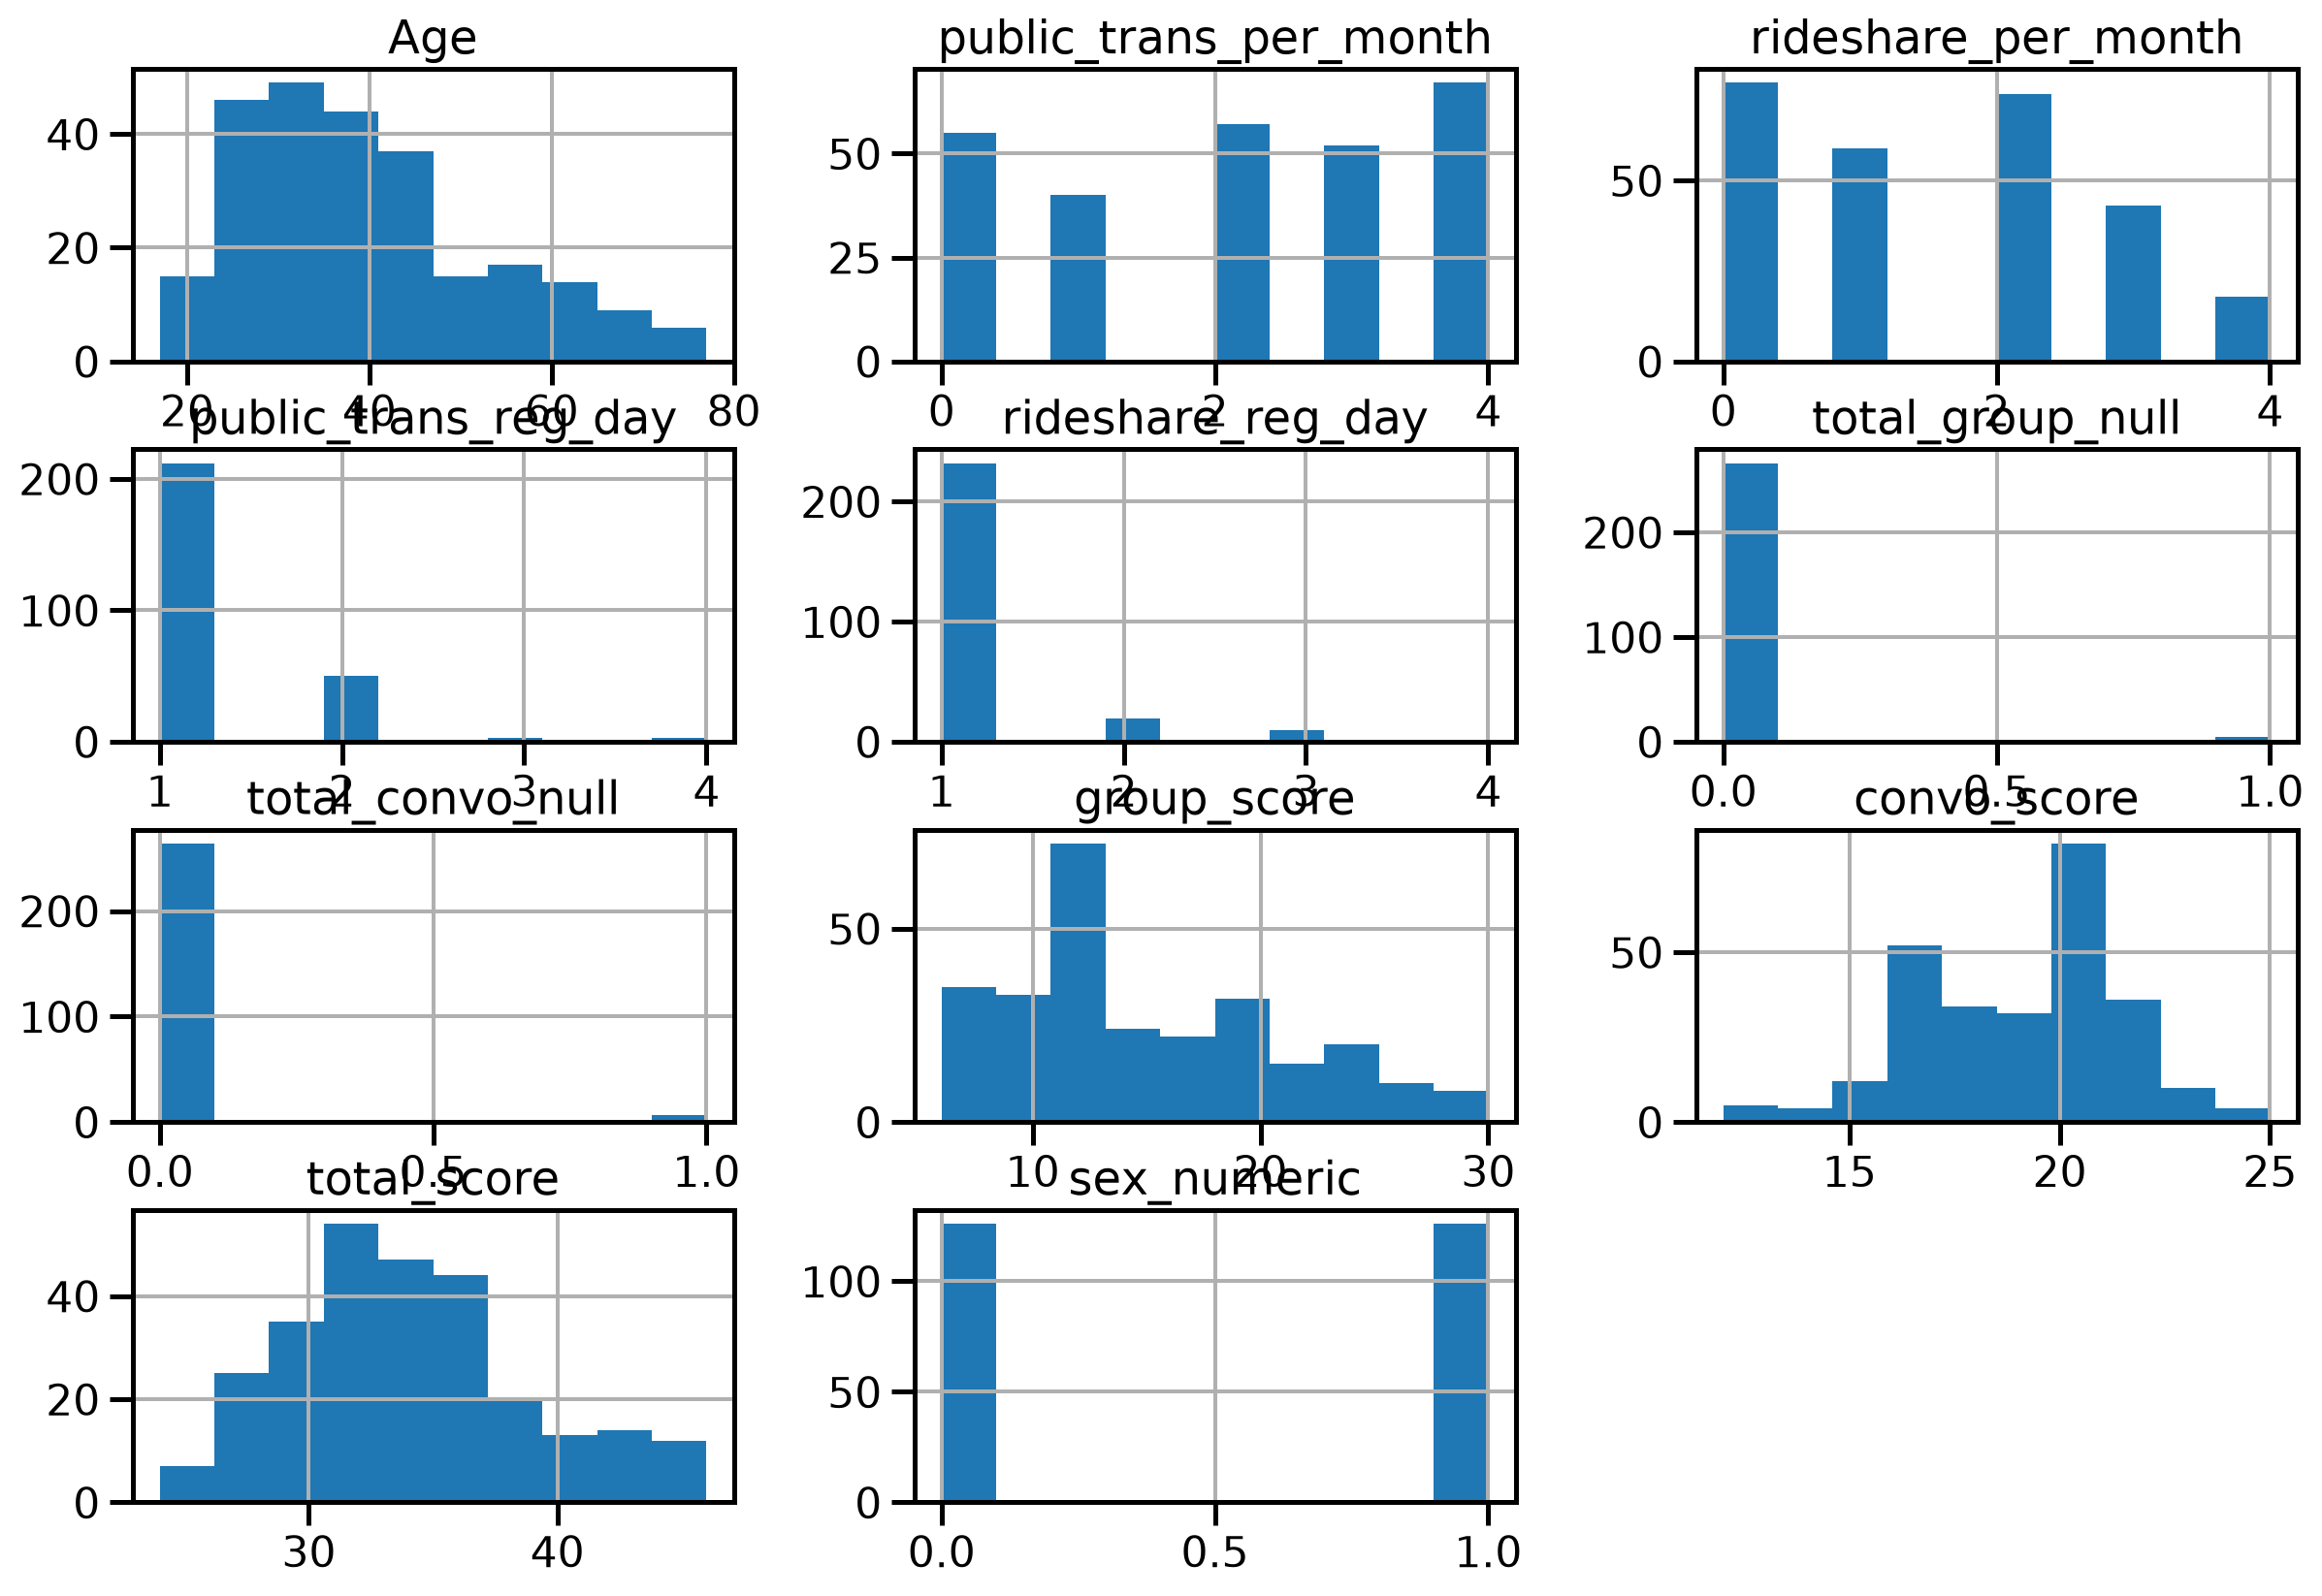

In [12]:
#| label: fig-histograms
#| fig-cap: Histograms of numeric variables
# Drop p_id column
df_plot = df.drop(columns=['p_id'])

df_plot.hist(figsize=(15, 10))
plt.show()

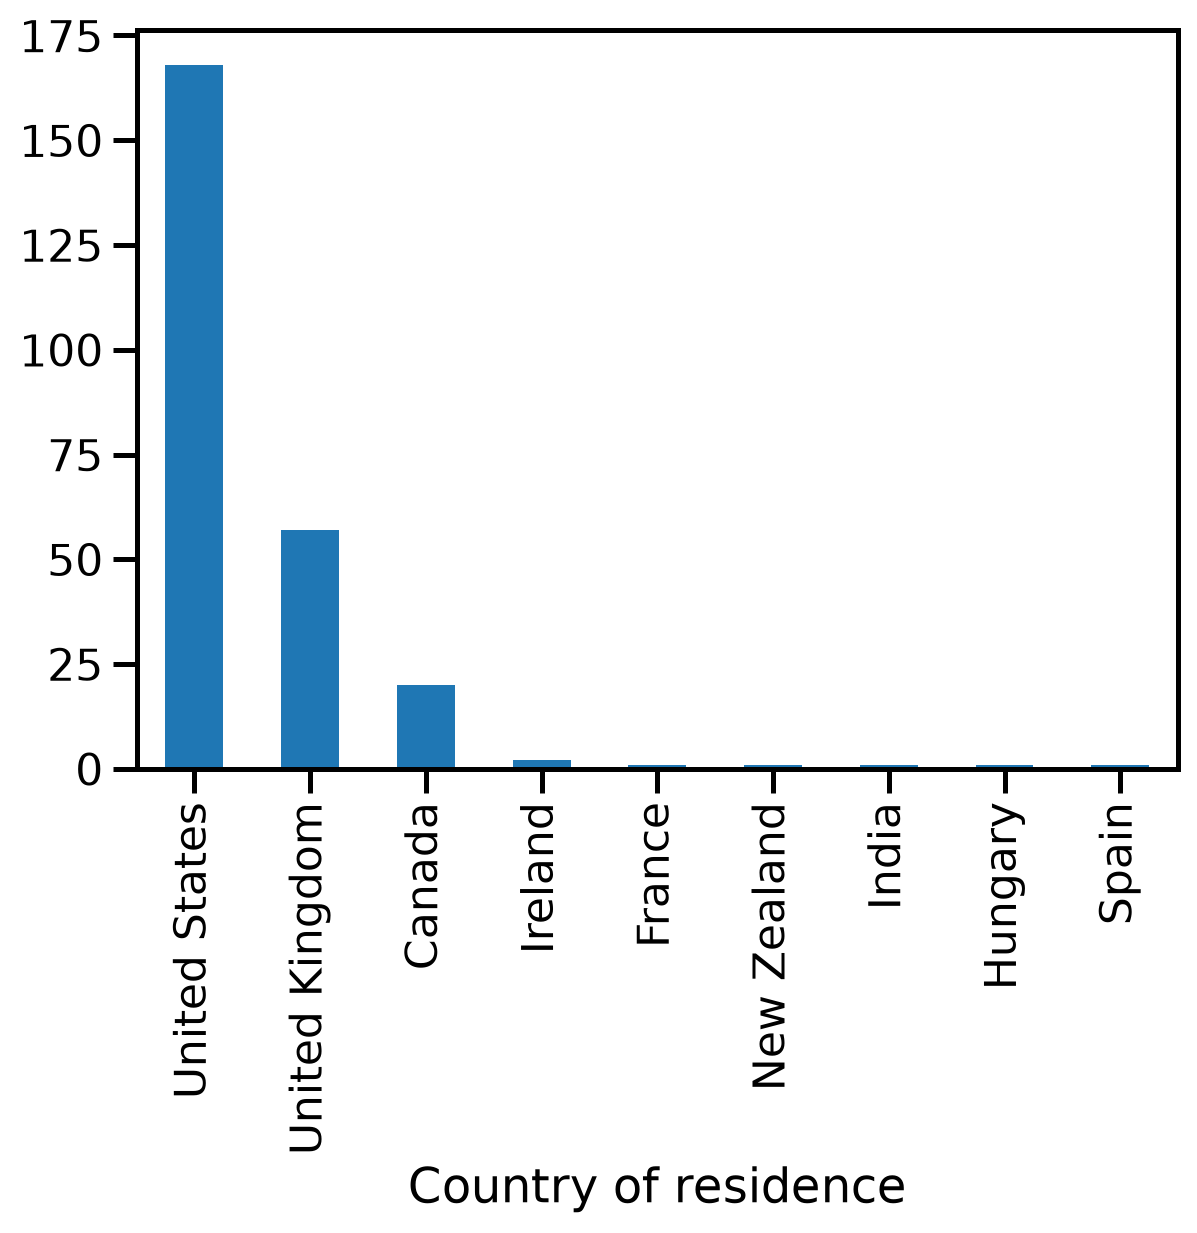

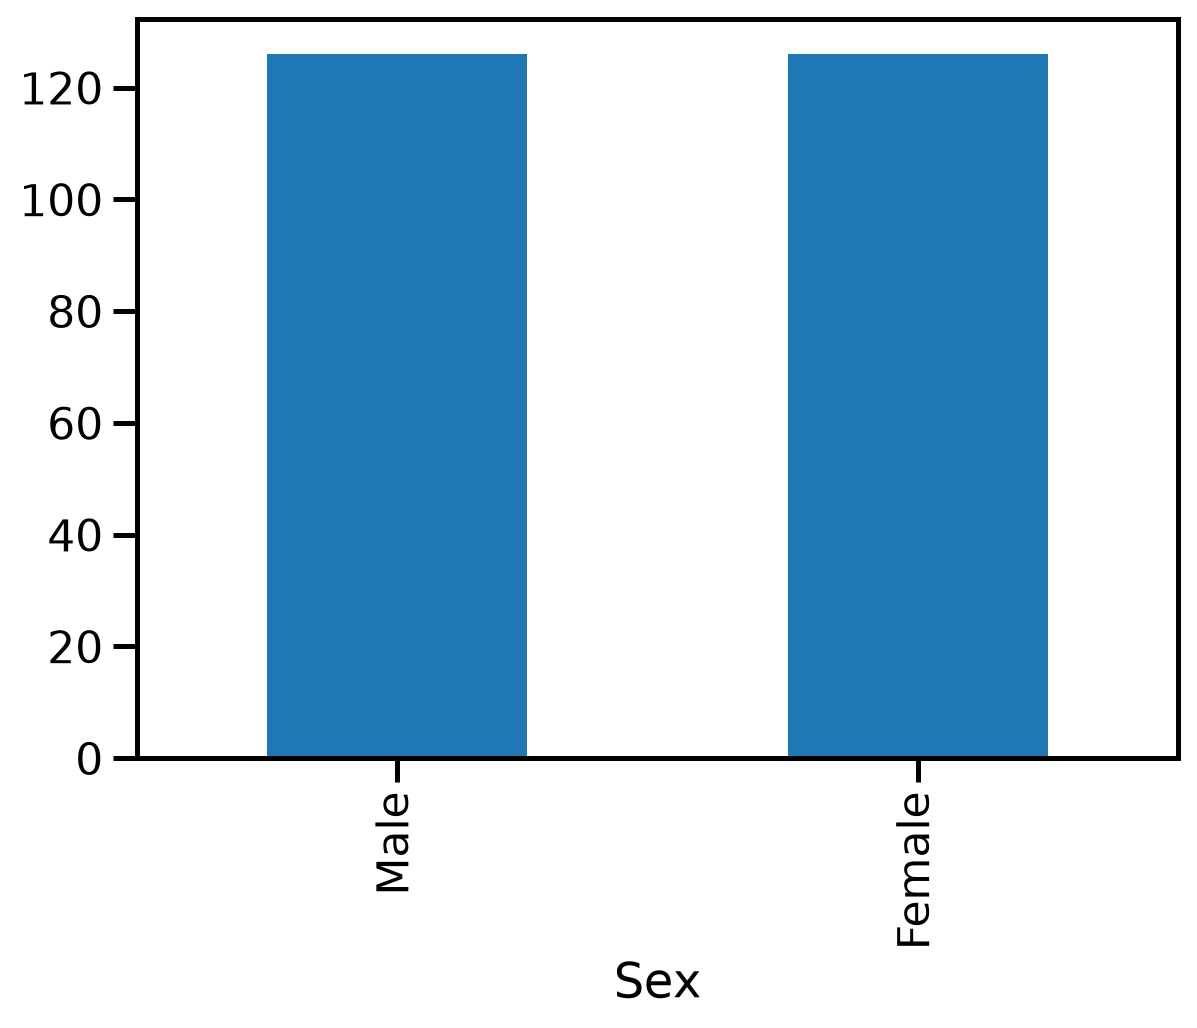

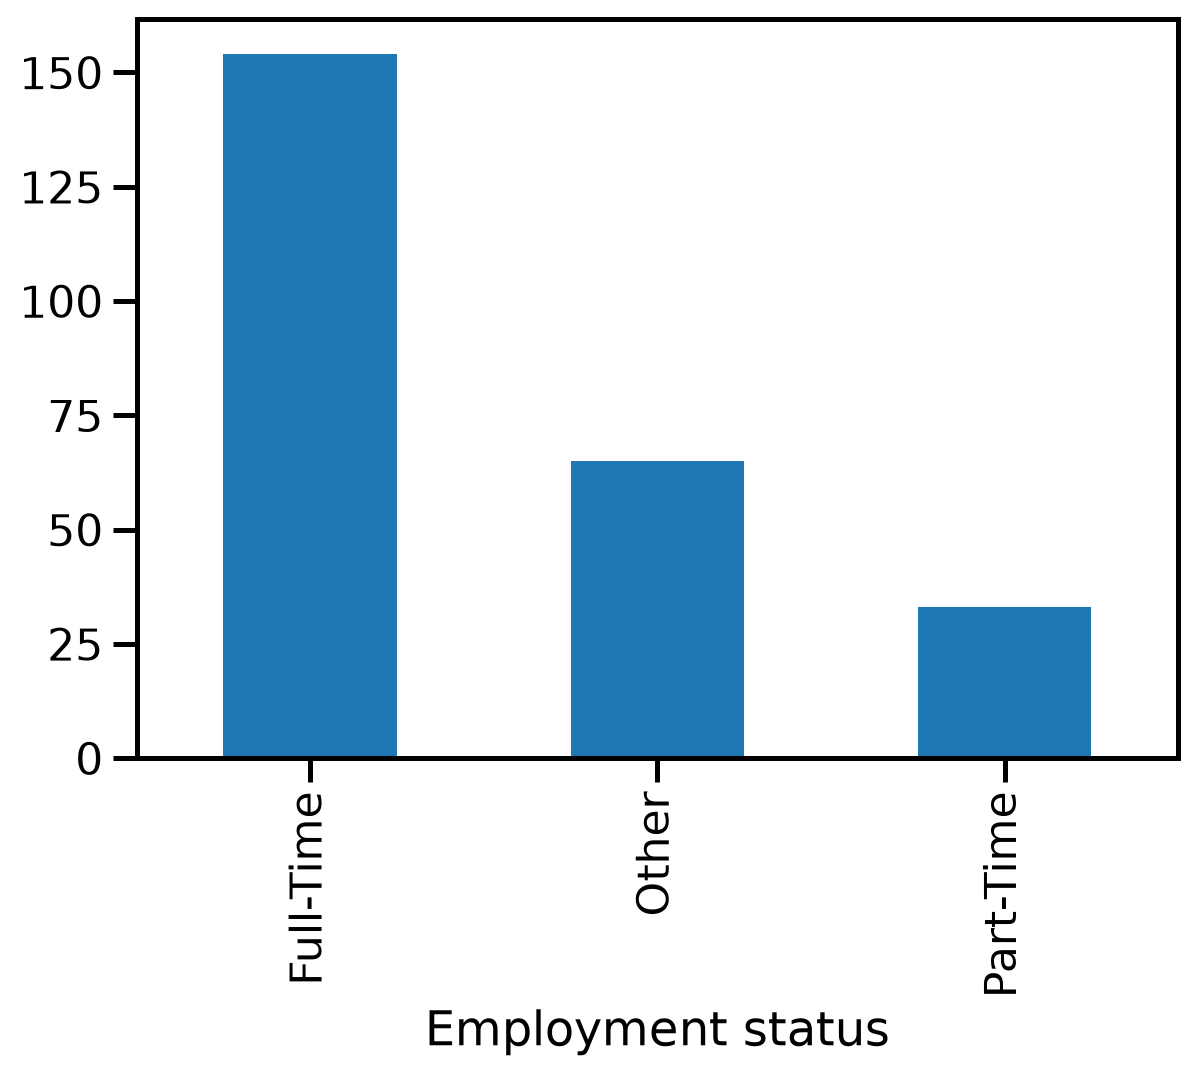

In [13]:
#| label: fig-barplots
#| fig-cap: Bar plots of categorical variables
#| fig-subcap:
#|   - Country of residence
#|   - Sex
#|   - Employment status
# Create bar plots for categorical variables there should be 3 barplots 

for col in ['Country of residence', 'Sex', 'Employment status']:
    df[col].value_counts().plot(kind='bar')
    plt.show()

In [14]:
#print out the rows in df that have null values in any of the columns
print(df[df.isnull().any(axis=1)])
print(df[df.isnull().any(axis=1)].shape)


     p_id   Age Total approvals     Sex Country of residence Student status  \
14     14  37.0            700+  Female        United States             No   
50     50  39.0            700+  Female       United Kingdom             No   
58     58  63.0            700+    Male        United States             No   
66     66   NaN             NaN     NaN                  NaN            NaN   
102   102   NaN             NaN     NaN                  NaN            NaN   
103   103   NaN             NaN     NaN                  NaN            NaN   
104   104   NaN             NaN     NaN                  NaN            NaN   
105   105   NaN             NaN     NaN                  NaN            NaN   
106   106   NaN             NaN     NaN                  NaN            NaN   
107   107   NaN             NaN     NaN                  NaN            NaN   
108   108   NaN             NaN     NaN                  NaN            NaN   
109   109   NaN             NaN     NaN             

Hypothesis: I believe full time employees have a lower ratio of public_trans_per_month to rideshare_per_month than part time and other types of employment status. full time employees should generally have a higher number of transportation days than someone that is part time or other.

People with access to a vehicle will have a lower ratio of public_trans_per_month to rideshare_per_month than those without access to a vehicle. The effect of employment status on transportation choices may be moderated by access to a vehicle, such that fulltime employment status with access to a vehicle will have a lower ratio of public_trans_per_month to rideshare_per_month than parttime employment status with access to a vehicle.

# Introduction

This is the introduction section. Add your content here.

# Methods

# Results

Add your results here.

# Discussion

Add your discussion here.

# References

```` markdown
---
title: "Qualtrics Data Cleaning Demo"
author: 
  - name: "Rachel Rapier"
    affiliation: "University of Wisconsin, Madison"
date: "2026-07-08"
abstract: |
  This manuscript cleans the data set and analyzes the relationship between enjoyment of social interaction and use of public transportation. 
jupyter: python3
echo: TRUE

---


## Standard Imports & Loacking Data

quarto-executable-code-5450563D

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_context('talk')
```



# Read in the Data

quarto-executable-code-5450563D

```python
dataA = pd.read_csv('data_orig/PRCAProlificExport_FileA.csv')
dataB = pd.read_csv('data_orig/PRCAProlificExport_FileB.csv')
dataC = pd.read_csv('data_orig/PRCAQualtricsExport_FileC.csv')

questions = pd.read_csv('data_dictionary.csv')


# rename the columns to variable_name and question
questions.rename(columns={questions.columns[0]: 'variable_name', questions.columns[1]: 'question'}, inplace=True)

```

quarto-executable-code-5450563D

```python
#| label: view-questions
#| echo: true
# with pd.option_context('display.max_colwidth', None):
#     display(questions.transpose())

Markdown(
  questions.transpose().to_markdown()
)

```



## Merge Files
quarto-executable-code-5450563D

```python
#| echo: true
# First merge dataB with dataA (both have Participant id column)
data_all = pd.merge(dataA, dataB, how = 'outer')

# Then merge the result with dataC (Q0 in dataC contains Participant id that matches Participant id in dataA/dataB)
data_all = pd.merge(data_all, dataC, left_on='Participant id', right_on='Q0', how='right')

#create an indexing column because participant id a long string of numbers and we want to simplify it. This index will be used as the participant id. Then move it to the first column

data_all['p_id'] = data_all.index
data_all = data_all[['p_id'] + [col for col in data_all.columns if col != 'p_id']]

# Display the merged dataframe info
print(f"Merged dataframe shape: {data_all.shape}")
print(f"Columns in merged dataframe: {data_all.columns.tolist()}")
print(data_all.head())
```

# Data Cleaning & Prep


## Response mapping to numeric values

quarto-executable-code-5450563D

```python
#| label: response-mapping

df = data_all
#make all responses lowercase
df = df.apply(lambda col: col.str.lower() if col.name.startswith('Q') else col)

# print("Unique responses in columns Q2-Q18:")
# for col in df.columns:
#     if col.startswith('Q'):
#       if not col.startswith('Q0'):
#         print(f"{col}: {df[col].dropna().unique()}")

# df["Q1"].value_counts()

# Show value counts for all Q columns
# for col in df.columns:
#     if col.startswith('Q') and not col.startswith('Q0'):
#         print(f"\n{col} value counts:")
#         print(df[col].value_counts(dropna=False))


# Find columns with identical unique values
from collections import defaultdict

# Get unique values for each Q column (excluding Q0)
q_unique_vals = {}
for col in df.columns:
    if col.startswith('Q') and not col.startswith('Q0'):
        unique_vals = tuple(sorted(df[col].dropna().unique()))
        q_unique_vals[col] = unique_vals

# Group columns by their unique values
value_groups = defaultdict(list)
for col, vals in q_unique_vals.items():
    value_groups[vals].append(col)

# Display groups
print("Columns with identical unique values:")
for i, (vals, cols) in enumerate(value_groups.items(), 1):
    print(f"\nGroup {i} ({len(cols)} columns): {cols}")
    print(f"  Values: {vals}")


# Create mapping dictionaries for each group
group1_mapping = {
    'strongly disagree': 1,
    'somewhat disagree': 2,
    'neither agree nor disagree': 3,
    'somewhat agree': 4,
    'strongly agree': 5
}

group2_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'never': 0
}

group3_mapping = {
  '1-2 rides in a typical day': 1, 
  '3-4 rides in a typical day': 2, 
  '5-6 rides in a typical day': 3, 
  '7 or more rides in a typical day': 4
}

group4_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'never': 0
}

# Create numeric columns for each response from all group mappings

for col in df.columns:
    if col in value_groups[tuple(sorted(group1_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group1_mapping)

# Create numeric columns for each response from group2_mapping
for col in df.columns:
    if col in value_groups[tuple(sorted(group2_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group2_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group3_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group3_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group4_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group4_mapping)

#reverse score Q2, Q4, Q6, Q13, Q15, Q17
df['Q2_numeric'] = 6 - df['Q2_numeric']
df['Q4_numeric'] = 6 - df['Q4_numeric']
df['Q6_numeric'] = 6 - df['Q6_numeric']
df['Q13_numeric'] = 6 - df['Q13_numeric']
df['Q15_numeric'] = 6 - df['Q15_numeric']
df['Q17_numeric'] = 6 - df['Q17_numeric']


# Show the new numeric columns
numeric_cols = [col for col in df.columns if col.endswith('_numeric')]
print(f"Created {len(numeric_cols)} numeric columns:")
print(df["Q21"].value_counts())  # Show first 10
```

## Create new Columns group_score, convo_score, and total_score

quarto-executable-code-5450563D

```python
#create a column in df total_group_null that is the sum of the nan values for questions q1:q6
df['total_group_null'] = df[['Q1_numeric', 'Q2_numeric', 'Q3_numeric', 'Q4_numeric', 'Q5_numeric', 'Q6_numeric']].isnull().sum(axis=1)

#do the same thing except call it total_convo_null that is the sum of the nan values for question q13:q18
df['total_convo_null'] = df[['Q13_numeric', 'Q14_numeric', 'Q15_numeric', 'Q16_numeric', 'Q17_numeric', 'Q18_numeric']].isnull().sum(axis=1)

df = df[(df['total_group_null'] != 6) & (df['total_convo_null'] != 6)]

# After all of that I now want to impute either the median or the mode of the question in group 1 and 2 that the participant did not answer. 

df = df.fillna(df[['Q1_numeric', 'Q2_numeric', 'Q3_numeric', 'Q4_numeric', 'Q5_numeric', 'Q6_numeric', 'Q13_numeric', 'Q14_numeric', 'Q15_numeric', 'Q16_numeric', 'Q17_numeric', 'Q18_numeric']].median())


print(df[['total_group_null', 'total_convo_null']])

#create a new column in df called group_score that is the sum of q1-q6
df['group_score'] = df[['Q1_numeric', 'Q2_numeric', 'Q3_numeric', 'Q4_numeric', 'Q5_numeric', 'Q6_numeric']].sum(axis=1, skipna=False)

#create a new column in df called convo_score that is the sum of qq13-q18
df['convo_score'] = df[['Q13_numeric', 'Q14_numeric', 'Q15_numeric', 'Q16_numeric', 'Q17_numeric', 'Q18_numeric']].sum(axis=1, skipna=False)

#create new column in df called total scores
df['total_score'] = df['group_score'] + df['convo_score']
df[['group_score', 'convo_score', 'total_score']].head()

#create a numeric sex column
df['sex_numeric'] = df['Sex'].map({'Male': 0, 'Female': 1})

#rename Q26 - Q29 to be more descriptive
df = df.rename(columns={
  'Q26_numeric': 'public_trans_per_month', 
  'Q27_numeric': 'public_trans_reg_day', 
  'Q28_numeric': 'rideshare_per_month', 
  'Q29_numeric': 'rideshare_reg_day'})
```

## Remove columns that I am not interested in: 

quarto-executable-code-5450563D

```python
df_before_drop = df

df = df.drop(columns=['EndDate', 'StartDate', 'LocationLatitude', 'LocationLongitude', 'Started at', 'Completed at', 'ResponseId', 'Participant id', 'Submission id'])


```



quarto-executable-code-5450563D

```python
#drop all columns that start with Q 
df = df.drop(columns=[col for col in df.columns if col.startswith('Q')])

```


## Check for unreasonable values in dataset

quarto-executable-code-5450563D

```python
#| label: tbl-describe_dataframe
#| tbl-cap: "Descriptive statistics for the cleaned dataset"
# Check for any unreasonable values in the dataset

# Create a mapping of variable names to human-readable descriptions
variable_descriptions = {
    'p_id': 'Participant ID',
    'group_score': 'Group Discussion Score (Q1-Q6)',
    'convo_score': 'Conversation Score (Q13-Q18)',
    'total_score': 'Total Social Interaction Score',
    'sex_numeric': 'Sex (0=Male, 1=Female)',
    'public_trans_per_month': 'Public Transportation Days per Month',
    'public_trans_reg_day': 'Public Transportation Rides per Typical Day',
    'rideshare_per_month': 'Rideshare Days per Month',
    'rideshare_reg_day': 'Rideshare Rides per Typical Day',
    'total_group_null': 'Missing Group Discussion Responses',
    'total_convo_null': 'Missing Conversation Responses',
    'Duration (in seconds)': 'Survey Duration (seconds)',
    'Time taken': 'Time Taken'
}

# Get the descriptive statistics and transpose
desc_stats = df.describe().transpose().apply(lambda x: round(x, 2))

# Add human-readable descriptions as a new column
desc_stats['variable_description'] = desc_stats.index.map(variable_descriptions)

# Drop the existing index and set the new column as the index
desc_stats = desc_stats.reset_index(drop=True).set_index('variable_description')

desc_stats
```

quarto-executable-code-5450563D

```python
for col in ['Country of residence', 'Sex', 'Employment status']:
    print(df[col].value_counts())
```

## Filter out participants with duration in seconds or time taken < 30 seconds

quarto-executable-code-5450563D

```python
# Filter out participants with duration in seconds or time taken < 30 seconds
# print( df[df['Duration (in seconds)']< 30])

df = df[df['Duration (in seconds)']> 30]

df = df.drop(columns=['Duration (in seconds)', 'Time taken'])

print(df.describe())

print(df.groupby('Employment status')[['public_trans_per_month', 'rideshare_per_month', 'public_trans_reg_day', 'rideshare_reg_day', 'rideshare_reg_day']].describe().T)

for col in ['Country of residence', 'Sex', 'Employment status']:
    print(df[col].value_counts())
```

## Create histograms for all numeric columns except p_id and bar plots with the value counts for categorical variables

quarto-executable-code-5450563D

```python
#| label: fig-histograms
#| fig-cap: "Histograms of numeric variables"

# Drop p_id column
df_plot = df.drop(columns=['p_id'])

df_plot.hist(figsize=(15, 10))
plt.show()
```

quarto-executable-code-5450563D

```python
#| label: fig-barplots
#| fig-cap: "Bar plots of categorical variables"
#| fig-subcap: ["Country of residence", "Sex", "Employment status"]

# Create bar plots for categorical variables there should be 3 barplots 

for col in ['Country of residence', 'Sex', 'Employment status']:
    df[col].value_counts().plot(kind='bar')
    plt.show()

```

quarto-executable-code-5450563D

```python
#print out the rows in df that have null values in any of the columns
print(df[df.isnull().any(axis=1)])
print(df[df.isnull().any(axis=1)].shape)



```

quarto-executable-code-5450563D

```python
```

Hypothesis: 
I believe full time employees have a lower ratio of public_trans_per_month to rideshare_per_month than part time and other types of employment status. full time employees should generally have a higher number of transportation days than someone that is part time or other. 

People with access to a vehicle will have a lower ratio of public_trans_per_month to rideshare_per_month than those without access to a vehicle. The effect of employment status on transportation choices may be moderated by access to a vehicle, such that fulltime employment status with access to a vehicle will have a lower ratio of public_trans_per_month to rideshare_per_month than parttime employment status with access to a vehicle.

quarto-executable-code-5450563D

```python
```

# Introduction

This is the introduction section. Add your content here.

# Methods


# Results

Add your results here.

# Discussion

Add your discussion here.

# References
````